## EDA and preprocessing of Titanic dataset followed by training an XGBoost model for survival prediction using an 80:20 data split.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [6]:
warnings.filterwarnings('ignore')

In [7]:
df=pd.read_csv("Titanic-Dataset.csv")
df.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C


In [8]:
df.tail(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [9]:
df.shape

(891, 12)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [11]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [12]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [13]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [14]:
df[df.duplicated()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


In [15]:
df.drop_duplicates(inplace=True)

In [16]:
df.reset_index(drop=True,inplace=True)

In [17]:
df.shape

(891, 12)

In [18]:
median=df["Age"].median()

In [19]:
df["Age"]=df["Age"].fillna(df["Age"].median())

In [20]:
df["Embarked"]=df["Embarked"].fillna(str(df["Embarked"].mode()))


In [21]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


<Axes: >

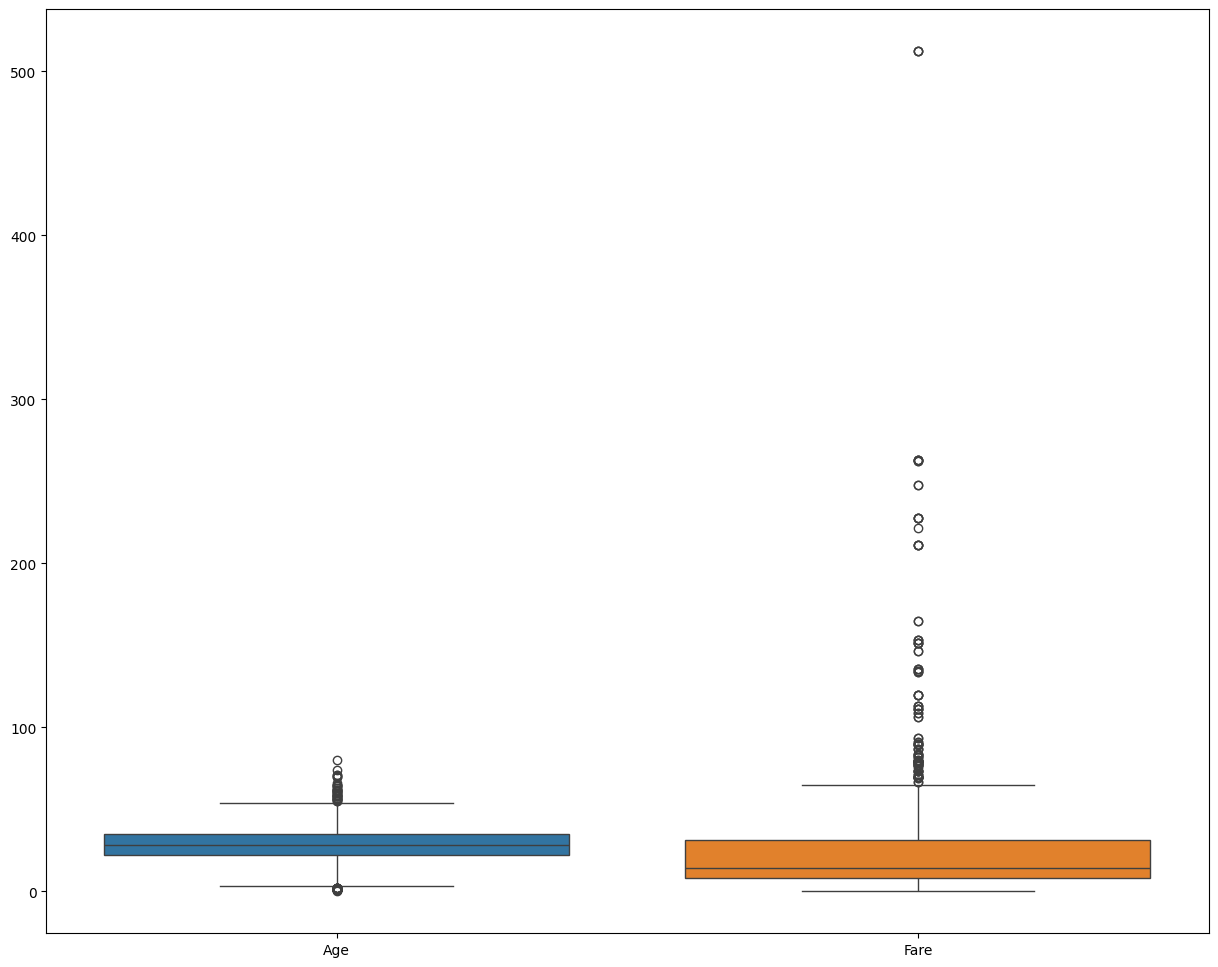

In [22]:
plt.figure(figsize=(15,12))
sns.boxplot(data=df[["Age","Fare"]])

In [23]:
def detect_outliers_iqr(data):
  outlier_list=[]
  data=sorted(data)
  q1=np.percentile(data,25)
  q3=np.percentile(data,75)
  IQR=q3-q1
  lower_bound=q1-(1.5*IQR)
  upper_bound=q3+(1.5*IQR)
  for i in data:
    if (i<lower_bound or i>upper_bound):
      outlier_list.append(i)
  return outlier_list
for  i in ['Age','Fare']:
  outliers=detect_outliers_iqr(df[i])
  print("Outliers in",i,"attribute: ",outliers)

Outliers in Age attribute:  [0.42, 0.67, 0.75, 0.75, 0.83, 0.83, 0.92, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 55.0, 55.0, 55.5, 56.0, 56.0, 56.0, 56.0, 57.0, 57.0, 58.0, 58.0, 58.0, 58.0, 58.0, 59.0, 59.0, 60.0, 60.0, 60.0, 60.0, 61.0, 61.0, 61.0, 62.0, 62.0, 62.0, 62.0, 63.0, 63.0, 64.0, 64.0, 65.0, 65.0, 65.0, 66.0, 70.0, 70.0, 70.5, 71.0, 71.0, 74.0, 80.0]
Outliers in Fare attribute:  [66.6, 66.6, 69.3, 69.3, 69.55, 69.55, 69.55, 69.55, 69.55, 69.55, 69.55, 71.0, 71.0, 71.2833, 73.5, 73.5, 73.5, 73.5, 73.5, 75.25, 76.2917, 76.7292, 76.7292, 76.7292, 77.2875, 77.2875, 77.9583, 77.9583, 77.9583, 78.2667, 78.2667, 78.85, 78.85, 79.2, 79.2, 79.2, 79.2, 79.65, 79.65, 79.65, 80.0, 80.0, 81.8583, 82.1708, 82.1708, 83.1583, 83.1583, 83.1583, 83.475, 83.475, 86.5, 86.5, 86.5, 89.1042, 89.1042, 90.0, 90.0, 90.0, 90.0, 91.0792, 91.0792, 93.5, 93.5, 106.425, 106.425, 108.9, 108.9, 110.8833, 110.8833, 110.8833, 110.8833, 113.275, 113.275, 113.275, 12

In [24]:
df["Sex"]=df["Sex"].replace("male",0)
df["Sex"]=df["Sex"].replace("female",1)

In [25]:
df["Embarked"].unique()

array(['S', 'C', 'Q', '0    S\nName: Embarked, dtype: object'],
      dtype=object)

In [26]:
df["Embarked"]=df["Embarked"].replace("S",0)
df["Embarked"]=df["Embarked"].replace("C",1)
df["Embarked"]=df["Embarked"].replace("Q",2)
df["Embarked"]=df["Embarked"].replace("0 S\ndtype: object",0)

In [27]:
df.head(15)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,1
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,0
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,0
5,6,0,3,"Moran, Mr. James",0,28.0,0,0,330877,8.4583,NaN,2
6,7,0,1,"McCarthy, Mr. Timothy J",0,54.0,0,0,17463,51.8625,E46,0
7,8,0,3,"Palsson, Master. Gosta Leonard",0,2.0,3,1,349909,21.0750,NaN,0
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",1,27.0,0,2,347742,11.1333,NaN,0
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",1,14.0,1,0,237736,30.0708,NaN,1


<Axes: xlabel='Sex', ylabel='count'>

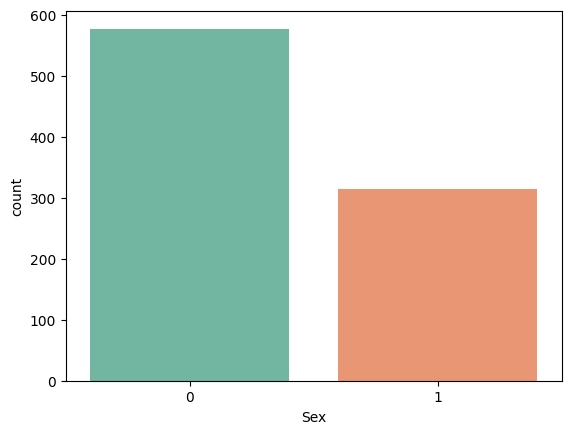

In [28]:
sns.countplot(x=df["Sex"],palette="Set2")

In [29]:
gender=round(df["Sex"].value_counts().values[0]/891*100)
print("Out of 891 {}% passengers are male".format(gender))

Out of 891 65% passengers are male


In [30]:
gender=round(df["Sex"].value_counts().values[1]/891*100)
print("Out of 891 {}% passengers are female".format(gender))

Out of 891 35% passengers are female


<Axes: xlabel='Fare', ylabel='count'>

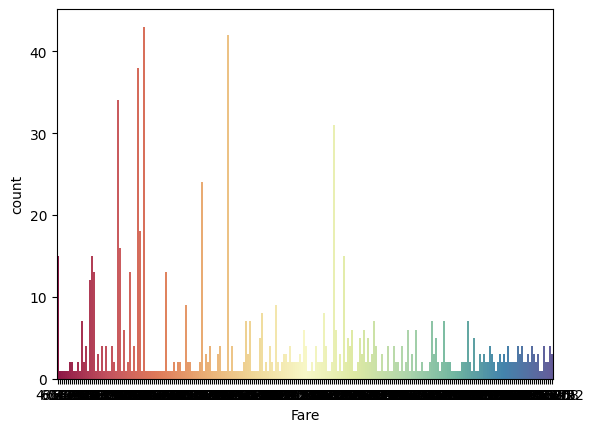

In [31]:
sns.countplot(x="Fare",data=df,palette='Spectral')

In [32]:
no_fare=round(df["Fare"].value_counts().values[0]/891*100)
fare=round(df["Fare"].value_counts().values[1]+df["Fare"].value_counts().values[2])
print("Out of 891 {}% passengers paid no fare".format(no_fare))
print("Out of 891 {}% passengers paid fare".format(fare))

Out of 891 5% passengers paid no fare
Out of 891 80% passengers paid fare


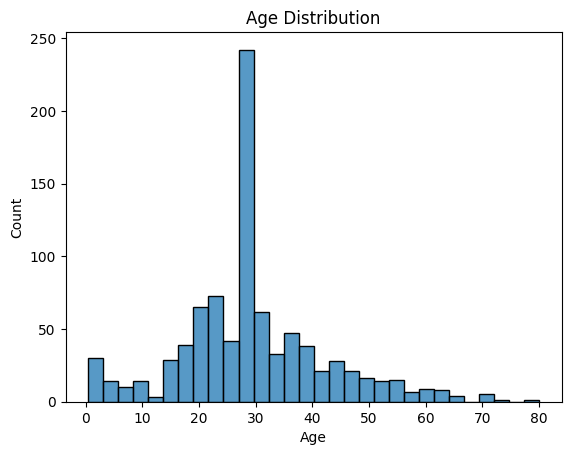

In [33]:
sns.histplot(df.Age)
plt.title("Age Distribution")
plt.show()

<Axes: xlabel='Sex', ylabel='Age'>

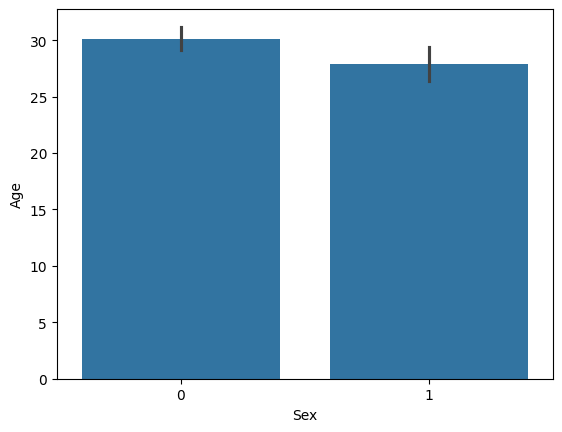

In [34]:
sns.barplot(x="Sex",y="Age",data=df)


<Axes: xlabel='Age', ylabel='Fare'>

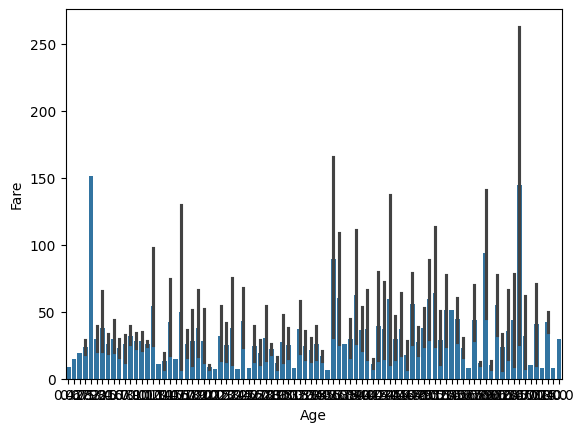

In [35]:
sns.barplot(x="Age",y="Fare",data=df)

<Axes: xlabel='Age', ylabel='Fare'>

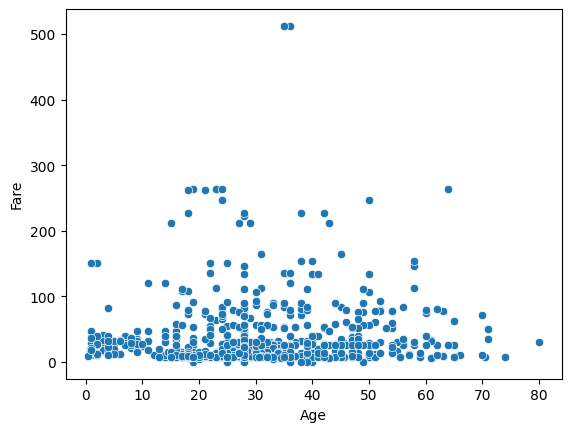

In [36]:
sns.scatterplot(x="Age",y="Fare",data=df)

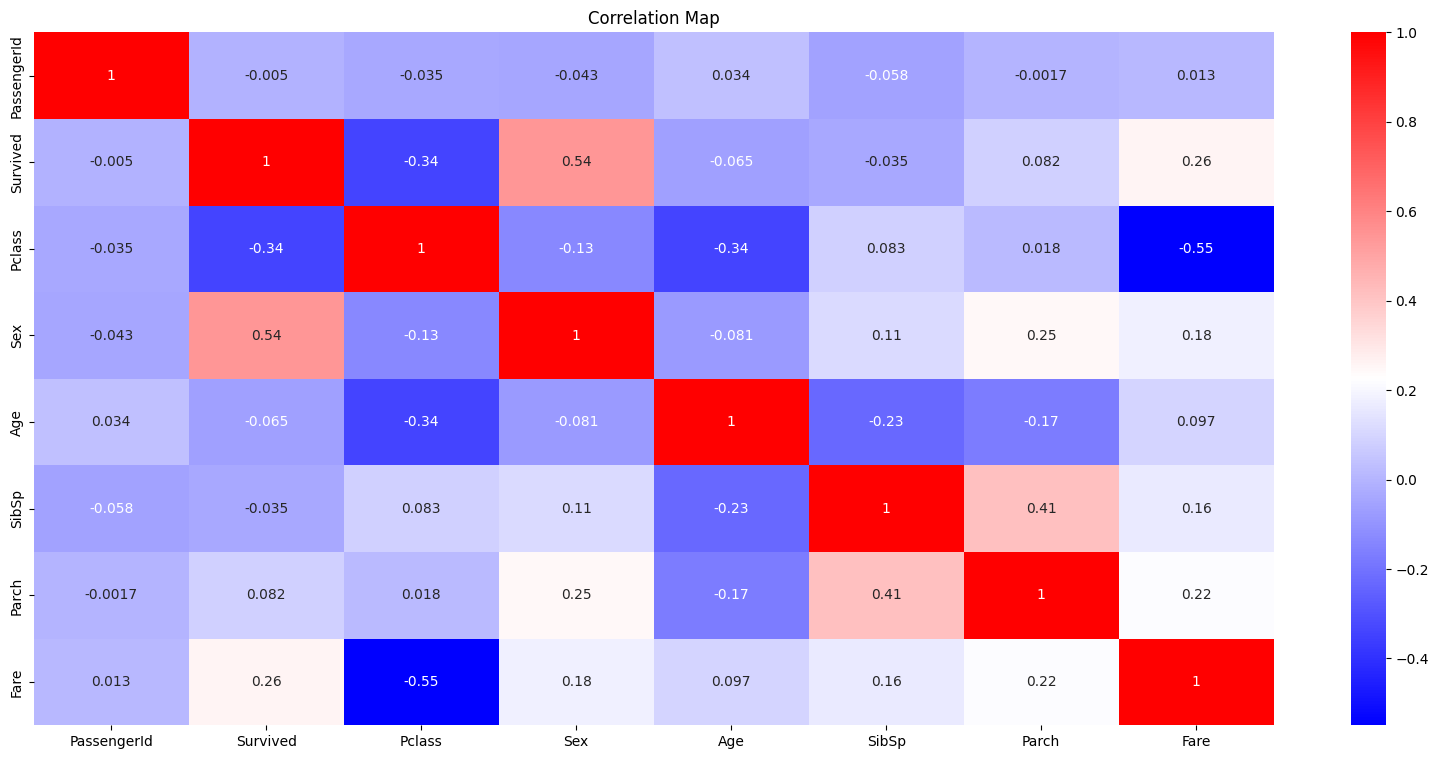

In [37]:
numeric_df= df.select_dtypes(include=[float, int])
corr_matrix = numeric_df.corr().fillna(0)
plt.figure(figsize=(20,9))
sns.heatmap(corr_matrix, annot=True, cmap='bwr')
plt.title('Correlation Map')
plt.show()

In [38]:
corr_matrix = numeric_df.corr()
corr_matrix["Survived"].sort_values(ascending=False)

,Survived
Survived,1.000000
Sex,0.543351
Fare,0.257307
Parch,0.081629
PassengerId,-0.005007
SibSp,-0.035322
Age,-0.064910
Pclass,-0.338481


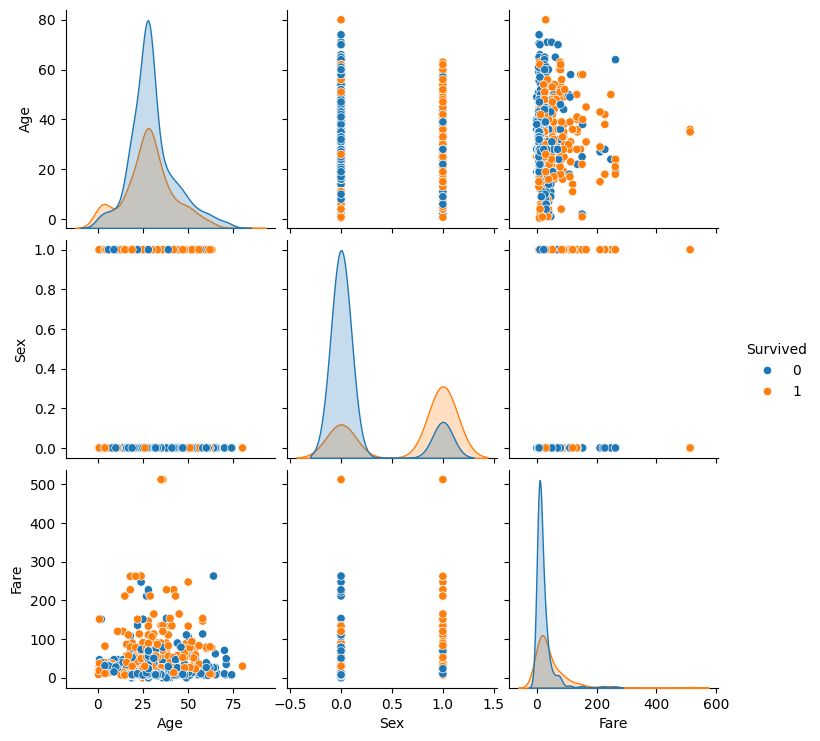

In [39]:
sns.pairplot(df[["Age","Sex","Fare","Survived"]],hue="Survived")

In [40]:
df.head(1)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.25,NaN,0


In [41]:
from sklearn.model_selection import train_test_split

In [42]:
feature_cols=["Age","Sex","Fare","Embarked"]
X=df[feature_cols]
y=df.Survived
X_train ,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)
X_train.shape

(712, 4)

In [48]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["Embarked"] = le.fit_transform(df["Embarked"].astype(str))
df["Sex"] = le.fit_transform(df["Sex"].astype(str))

XGBoost Improved Model Results
Accuracy: 0.7988826815642458
Precision: 0.7619047619047619
Recall: 0.6956521739130435
F1 Score: 0.7272727272727273

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.86      0.84       110
           1       0.76      0.70      0.73        69

    accuracy                           0.80       179
   macro avg       0.79      0.78      0.78       179
weighted avg       0.80      0.80      0.80       179



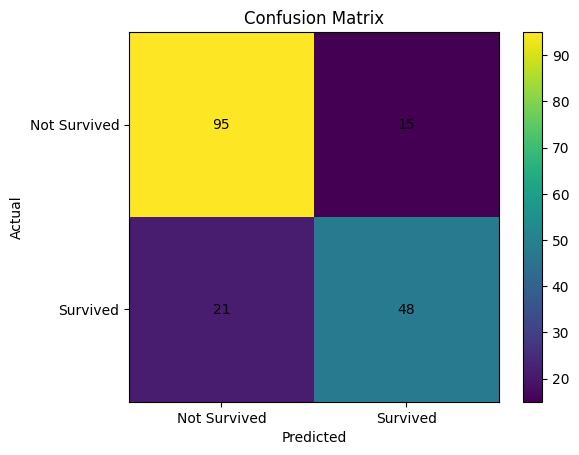

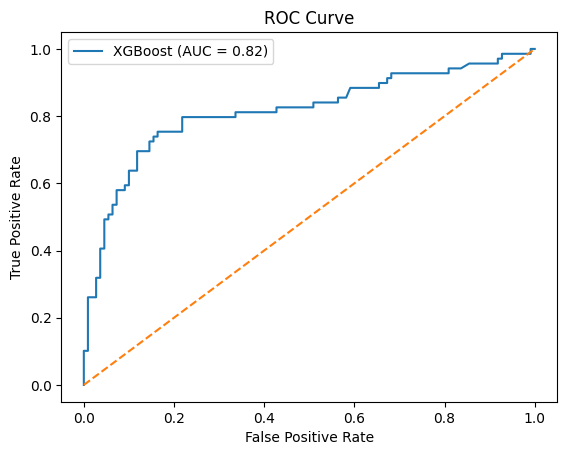

In [52]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

import matplotlib.pyplot as plt
from xgboost import XGBClassifier

df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df["Fare"] = df["Fare"].fillna(df["Fare"].median())

df["Fare"] = np.log1p(df["Fare"])

df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)


le = LabelEncoder()
df["Sex"] = le.fit_transform(df["Sex"])
df["Embarked"] = le.fit_transform(df["Embarked"].astype(str))

feature_cols = [
    "Pclass",
    "Sex",
    "Age",
    "Fare",
    "Embarked",
    "FamilySize",
    "IsAlone"
]

X = df[feature_cols]
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,
    eval_metric='logloss'
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]


print("XGBoost Improved Model Results")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks([0, 1], ["Not Survived", "Survived"])
plt.yticks([0, 1], ["Not Survived", "Survived"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label=f"XGBoost (AUC = {auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()